<a href="https://colab.research.google.com/github/zeosapka/glass-box-ai-research/blob/main/notebooks/10_statistical_control_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# ============================================================
# E09 — 50 Random Control Statistical Test
# Amaç:
# Aday dimension 496'nın çıktı etkisini 50 random control
# dimension ile karşılaştırmak ve istatistiksel olarak
# ne kadar sıra dışı olduğunu ölçmek.
# ============================================================

import numpy as np
import pandas as pd
import torch

# Deneyin tekrar üretilebilir olması için sabit seed
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

# E08'den gelen aday dimension
CANDIDATE_DIM = 496

# Karşılaştırılacak random control sayısı
N_CONTROLS = 50

print("E09 setup hazır.")
print("Candidate dimension:", CANDIDATE_DIM)
print("Number of random controls:", N_CONTROLS)
print("Seed:", SEED)

E09 setup hazır.
Candidate dimension: 496
Number of random controls: 50
Seed: 42


In [21]:
# ============================================================
# E09 — Model ve Tokenizer
# Amaç:
# E09 deneyinde kullanılacak DistilGPT-2 modelini ve tokenizer'ı
# yüklemek ve hidden representation boyutunu doğrulamak.
# ============================================================

from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "distilgpt2"

# Tokenizer metni modelin anlayabileceği tokenlara dönüştürür.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Causal Language Model:
# Hidden state üzerinde yaptığımız müdahalenin model çıktısına
# nasıl yansıdığını ölçebilmemizi sağlar.
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

# GPU varsa kullan, yoksa CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

# DistilGPT-2'nin 6. Transformer bloğu
TARGET_LAYER = model.transformer.h[5]

# Hidden representation boyutu
HIDDEN_SIZE = model.config.n_embd

print("Model:", MODEL_NAME)
print("Device:", device)
print("Target layer: 5")
print("Hidden size:", HIDDEN_SIZE)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Model: distilgpt2
Device: cpu
Target layer: 5
Hidden size: 768


In [22]:
# ============================================================
# E09 — Test Cümlesi ve Baseline
# Amaç:
# E08'de kullanılan test cümlesi üzerinden modelin herhangi
# bir müdahale uygulanmadan verdiği baseline çıktıyı oluşturmak.
# ============================================================

# E08'de kullanılan test cümlesi
test_sentence = "The cat is sitting on the mat."

# Cümleyi tokenlara dönüştür
inputs = tokenizer(
    test_sentence,
    return_tensors="pt"
).to(device)

# Müdahalesiz model çıktısını hesapla
with torch.no_grad():
    baseline_outputs = model(**inputs)

# Son token için logits
baseline_logits = baseline_outputs.logits[:, -1, :]

# Logits değerlerini olasılıklara dönüştür
baseline_probs = torch.softmax(
    baseline_logits,
    dim=-1
)

print("Test sentence:")
print(test_sentence)

print("\nInput shape:", tuple(inputs["input_ids"].shape))
print("Vocabulary size:", baseline_probs.shape[-1])
print("Baseline probability sum:", baseline_probs.sum().item())

Test sentence:
The cat is sitting on the mat.

Input shape: (1, 8)
Vocabulary size: 50257
Baseline probability sum: 1.0000156164169312


In [23]:
# ============================================================
# E09 — Target Layer Output Verification
# Amaç:
# Müdahale edeceğimiz Transformer katmanının gerçekten hangi
# tensor yapısını döndürdüğünü doğrulamak.
# ============================================================

layer_info = {}

def inspect_layer_output(module, module_input, module_output):
    # Layer çıktısının Python tipini kaydet
    layer_info["type"] = type(module_output).__name__

    # Tensor ise doğrudan şeklini kaydet
    if torch.is_tensor(module_output):
        layer_info["shape"] = tuple(module_output.shape)
        layer_info["ndim"] = module_output.ndim

    # Tuple / benzeri bir yapı ise elemanlarını incele
    else:
        layer_info["length"] = len(module_output)

        for i, item in enumerate(module_output):
            if torch.is_tensor(item):
                layer_info[f"item_{i}_shape"] = tuple(item.shape)
                layer_info[f"item_{i}_type"] = type(item).__name__

    return module_output


# Geçici hook
inspection_hook = TARGET_LAYER.register_forward_hook(
    inspect_layer_output
)

# Bir kez forward pass çalıştır
with torch.no_grad():
    _ = model(**inputs)

# Geçici hook'u kaldır
inspection_hook.remove()

print("Target layer output type:", layer_info["type"])
print("Layer information:")

for key, value in layer_info.items():
    print(f"  {key}: {value}")

Target layer output type: Tensor
Layer information:
  type: Tensor
  shape: (1, 8, 768)
  ndim: 3


In [24]:
# ============================================================
# E09 — Hidden Dimension Intervention Function
# Amaç:
# Seçilen hidden dimension'ı belirli miktarda standart sapma
# kadar değiştirerek model çıktısındaki L1 değişimini ölçmek.
# ============================================================

def calculate_intervention_effect(
    dimension,
    intervention_sigma,
    inputs,
    baseline_probs
):
    """
    Seçilen hidden dimension üzerinde müdahale yapar.

    dimension:
        Müdahale edilecek hidden dimension.

    intervention_sigma:
        Dimension'ın standart sapmasının kaç katı kadar
        değişiklik uygulanacağı.

    Dönen değerler:
        L1 çıktı değişimi ve kullanılan sigma.
    """

    captured = {}

    # --------------------------------------------------------
    # Hook:
    # Transformer layer çıktısını yakalar ve seçilen
    # hidden dimension üzerinde müdahale yapar.
    # --------------------------------------------------------
    def intervention_hook(module, module_input, module_output):

        # Target layer doğrudan Tensor döndürüyor.
        # Shape: (batch, sequence, hidden_size)
        hidden_states = module_output

        # Seçilen dimension'ın tokenlar üzerindeki
        # standart sapmasını hesapla.
        sigma = hidden_states[:, :, dimension].std()

        # Orijinal hidden state'i değiştirmemek için kopyala.
        modified_hidden = hidden_states.clone()

        # x → x + intervention_sigma × sigma
        modified_hidden[:, :, dimension] += (
            intervention_sigma * sigma
        )

        captured["sigma"] = sigma.item()

        # Değiştirilmiş Tensor'ü Transformer'a geri ver.
        return modified_hidden

    # Hook'u hedef layer'a bağla.
    hook = TARGET_LAYER.register_forward_hook(
        intervention_hook
    )

    try:
        # Müdahale edilmiş forward pass
        with torch.no_grad():
            outputs = model(**inputs)

        # Son token logits
        intervention_logits = outputs.logits[:, -1, :]

        # Logits → probability
        intervention_probs = torch.softmax(
            intervention_logits,
            dim=-1
        )

    finally:
        # Hook'u mutlaka kaldır.
        hook.remove()

    # Baseline ile müdahale edilmiş çıktı arasındaki
    # toplam mutlak fark = L1 distance
    l1_change = torch.sum(
        torch.abs(
            intervention_probs - baseline_probs
        )
    ).item()

    return l1_change, captured["sigma"]


print("Intervention function hazır.")

Intervention function hazır.


In [25]:
# ============================================================
# E09 — Candidate Dimension 496
# Amaç:
# Aday dimension 496 için beş farklı müdahale seviyesinde
# model çıktısındaki L1 değişimini ölçmek.
# ============================================================

CANDIDATE_DIM = 496

# E08'de kullanılan müdahale seviyeleri
INTERVENTION_LEVELS = [
    -0.25,
    -0.50,
    -1.00,
    +0.50,
    +1.00
]

candidate_results = []

for level in INTERVENTION_LEVELS:

    # Aday dimension'a müdahale uygula
    l1_change, sigma = calculate_intervention_effect(
        dimension=CANDIDATE_DIM,
        intervention_sigma=level,
        inputs=inputs,
        baseline_probs=baseline_probs
    )

    candidate_results.append({
        "dimension": CANDIDATE_DIM,
        "intervention_sigma": level,
        "l1_change": l1_change,
        "sigma": sigma
    })

# Sonuçları tabloya dönüştür
candidate_df = pd.DataFrame(candidate_results)

print("Candidate dimension:", CANDIDATE_DIM)
print()
print(candidate_df.to_string(index=False))

Candidate dimension: 496

 dimension  intervention_sigma  l1_change     sigma
       496               -0.25   0.005737 17.236246
       496               -0.50   0.011324 17.236246
       496               -1.00   0.022070 17.236246
       496                0.50   0.011875 17.236246
       496                1.00   0.024281 17.236246


In [26]:
# ============================================================
# E09 — Random Control Dimensions
# Amaç:
# Aday dimension 496 dışında 50 farklı hidden dimension
# seçerek kontrol grubunu oluşturmak.
# ============================================================

# Hidden size = 768 olduğu için geçerli dimensionlar:
# 0, 1, 2, ..., 767
all_dimensions = np.arange(HIDDEN_SIZE)

# Aday dimension'ı kontrol havuzundan çıkar
control_pool = all_dimensions[
    all_dimensions != CANDIDATE_DIM
]

# Tekrarsız 50 random control seç
control_dimensions = np.random.choice(
    control_pool,
    size=N_CONTROLS,
    replace=False
)

# Kontrolleri sıralı hale getirerek kayıtları okunabilir yap
control_dimensions = np.sort(control_dimensions)

print("Number of controls:", len(control_dimensions))
print("Candidate excluded:", CANDIDATE_DIM not in control_dimensions)
print()
print("Control dimensions:")
print(control_dimensions)

Number of controls: 50
Candidate excluded: True

Control dimensions:
[ 30  31  33  39  66  67  77  78  86  97 120 148 199 204 208 209 212 213
 265 281 299 300 324 328 336 338 356 363 383 424 436 451 456 486 498 501
 522 544 568 579 582 604 614 620 624 635 639 668 690 707]


In [27]:
# ============================================================
# E09 — Random Control Interventions
# Amaç:
# 50 random control dimension'ın her biri için E08'deki aynı
# beş müdahale seviyesinde L1 çıktı değişimini ölçmek.
# ============================================================

control_results = []

for dimension in control_dimensions:

    for level in INTERVENTION_LEVELS:

        # Kontrol dimension'a aynı müdahaleyi uygula
        l1_change, sigma = calculate_intervention_effect(
            dimension=dimension,
            intervention_sigma=level,
            inputs=inputs,
            baseline_probs=baseline_probs
        )

        control_results.append({
            "dimension": int(dimension),
            "intervention_sigma": level,
            "l1_change": l1_change,
            "sigma": sigma
        })

# Sonuçları DataFrame'e dönüştür
control_df = pd.DataFrame(control_results)

print("Control measurements:", len(control_df))
print("Expected measurements:", N_CONTROLS * len(INTERVENTION_LEVELS))
print()

print(control_df.head(10).to_string(index=False))

Control measurements: 250
Expected measurements: 250

 dimension  intervention_sigma  l1_change    sigma
        30               -0.25   0.004050 3.170809
        30               -0.50   0.008083 3.170809
        30               -1.00   0.016101 3.170809
        30                0.50   0.008140 3.170809
        30                1.00   0.016356 3.170809
        31               -0.25   0.003873 2.000211
        31               -0.50   0.007756 2.000211
        31               -1.00   0.015518 2.000211
        31                0.50   0.007738 2.000211
        31                1.00   0.015463 2.000211


In [28]:
# ============================================================
# E09 — Control Effect Aggregation
# Amaç:
# Her random control dimension'ın beş müdahale seviyesindeki
# L1 etkilerini tek bir ortalama etki değerinde toplamak.
# ============================================================

# Her dimension için beş müdahalenin ortalama L1 etkisini hesapla
control_summary = (
    control_df
    .groupby("dimension")["l1_change"]
    .mean()
    .reset_index()
    .rename(columns={"l1_change": "mean_l1_effect"})
)

# Aday dimension için de aynı yöntemi kullan
candidate_mean_effect = candidate_df["l1_change"].mean()

print("Candidate mean L1 effect:")
print(f"{candidate_mean_effect:.6f}")

print("\nControl dimensions:")
print(control_summary.to_string(index=False))

print("\nNumber of control dimensions:", len(control_summary))

Candidate mean L1 effect:
0.015057

Control dimensions:
 dimension  mean_l1_effect
        30        0.010546
        31        0.010070
        33        0.014197
        39        0.008983
        66        0.006762
        67        0.013502
        77        0.019298
        78        0.013767
        86        0.005675
        97        0.009385
       120        0.015171
       148        0.012887
       199        0.008583
       204        0.013022
       208        0.008987
       209        0.008047
       212        0.010757
       213        0.012421
       265        0.010585
       281        0.007302
       299        0.013232
       300        0.011908
       324        0.011692
       328        0.008983
       336        0.030683
       338        0.007709
       356        0.015629
       363        0.005450
       383        0.014479
       424        0.010863
       436        0.005477
       451        0.008824
       456        0.016157
       486        0.009829

In [29]:
# ============================================================
# E09 — Statistical Test
# Amaç:
# 50 random control dimension'ın ortalama ve standart
# sapmasını hesaplamak; aday dimension'ın z-score ve
# percentile değerini belirlemek.
# ============================================================

# 50 kontrolün ortalama L1 etkileri
control_effects = control_summary["mean_l1_effect"].to_numpy()

# Kontrol grubunun ortalaması
control_mean = np.mean(control_effects)

# Kontrol grubunun standart sapması
# ddof=1 → sample standard deviation
control_std = np.std(control_effects, ddof=1)

# E09 ödevindeki z-score formülü
z_score = (
    candidate_mean_effect - control_mean
) / control_std

# Adaydan daha küçük veya eşit olan kontrol sayısı
n_below = np.sum(
    control_effects <= candidate_mean_effect
)

# Empirical percentile
percentile = (
    n_below / len(control_effects)
) * 100

print("E09 Statistical Results")
print("=" * 50)

print(f"Candidate mean L1 : {candidate_mean_effect:.6f}")
print(f"Control mean       : {control_mean:.6f}")
print(f"Control std        : {control_std:.6f}")
print(f"Z-score            : {z_score:.6f}")
print(f"Percentile         : {percentile:.2f}%")

print("\nSuccess criteria")
print("=" * 50)

print(
    "|z| >= 2:",
    abs(z_score) >= 2
)

print(
    "Percentile >= 90:",
    percentile >= 90
)

print(
    "Overall E09 criterion:",
    abs(z_score) >= 2 and percentile >= 90
)

E09 Statistical Results
Candidate mean L1 : 0.015057
Control mean       : 0.011293
Control std        : 0.004407
Z-score            : 0.854322
Percentile         : 84.00%

Success criteria
|z| >= 2: False
Percentile >= 90: False
Overall E09 criterion: False


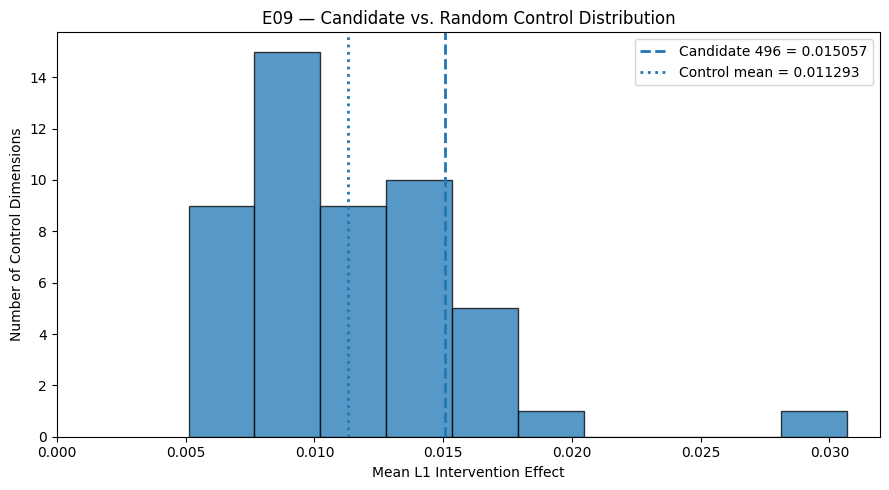

In [32]:
# ============================================================
# E09 — Control Distribution Visualization
# Amaç:
# 50 random control dimension'ın mean L1 effect dağılımını
# göstermek ve candidate dimension 496'nın konumunu
# 0'dan başlayan bir x ekseni üzerinde karşılaştırmak.
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.hist(
    control_effects,
    bins=10,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    candidate_mean_effect,
    linestyle="--",
    linewidth=2,
    label=f"Candidate 496 = {candidate_mean_effect:.6f}"
)

plt.axvline(
    control_mean,
    linestyle=":",
    linewidth=2,
    label=f"Control mean = {control_mean:.6f}"
)

# L1 effect negatif olamayacağı için ekseni 0'dan başlatıyoruz
plt.xlim(left=0)

plt.xlabel("Mean L1 Intervention Effect")
plt.ylabel("Number of Control Dimensions")
plt.title("E09 — Candidate vs. Random Control Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# E09 — Final Statistical Summary
# Amaç:
# E09 deneyinin temel istatistiklerini tek bir tabloda
# toplamak ve önceden belirlenen başarı kriterlerinin
# karşılanıp karşılanmadığını kaydetmek.
# ============================================================

e09_summary = pd.DataFrame({
    "metric": [
        "Candidate mean L1 effect",
        "Control mean L1 effect",
        "Control standard deviation",
        "Z-score",
        "Empirical percentile",
        "|z| >= 2 criterion",
        "Percentile >= 90 criterion",
        "Overall E09 criterion"
    ],
    "value": [
        candidate_mean_effect,
        control_mean,
        control_std,
        z_score,
        percentile,
        abs(z_score) >= 2,
        percentile >= 90,
        abs(z_score) >= 2 and percentile >= 90
    ]
})

print("E09 — Final Statistical Summary")
print("=" * 60)
print(e09_summary.to_string(index=False))

E09 — Final Statistical Summary
                    metric     value
  Candidate mean L1 effect  0.015057
    Control mean L1 effect  0.011293
Control standard deviation  0.004407
                   Z-score  0.854322
      Empirical percentile      84.0
        |z| >= 2 criterion     False
Percentile >= 90 criterion     False
     Overall E09 criterion     False


In [34]:
# ============================================================
# E09 — Interpretation and Conclusion
# Amaç:
# İstatistiksel sonuçları önceden tanımlanan başarı kriterleri
# ile karşılaştırmak ve deneyin bilimsel yorumunu kaydetmek.
# ============================================================

if abs(z_score) >= 2 and percentile >= 90:
    e09_status = "PASS"
    e09_conclusion = (
        "Candidate dimension 496 shows strong statistical "
        "separation from the random-control distribution."
    )
else:
    e09_status = "FAIL"
    e09_conclusion = (
        "Candidate dimension 496 has a higher mean L1 effect "
        "than the control mean, but it does not show sufficient "
        "statistical separation from the random-control "
        "distribution under the predefined E09 criteria."
    )

print("E09 — Final Interpretation")
print("=" * 60)
print(f"Status: {e09_status}")
print()
print(e09_conclusion)
print()
print("Key results:")
print(f"- Candidate mean L1 effect: {candidate_mean_effect:.6f}")
print(f"- Control mean: {control_mean:.6f}")
print(f"- Control standard deviation: {control_std:.6f}")
print(f"- Z-score: {z_score:.6f}")
print(f"- Empirical percentile: {percentile:.2f}%")

E09 — Final Interpretation
Status: FAIL

Candidate dimension 496 has a higher mean L1 effect than the control mean, but it does not show sufficient statistical separation from the random-control distribution under the predefined E09 criteria.

Key results:
- Candidate mean L1 effect: 0.015057
- Control mean: 0.011293
- Control standard deviation: 0.004407
- Z-score: 0.854322
- Empirical percentile: 84.00%
